# Sentinela — 01. EDA e Preparação dos Dados

## 1. Objetivo

Este notebook carrega, valida e prepara o dataset real de incidentes (`LWDATASET.xlsx`),
construindo a série temporal diária que alimenta o Motor Preditivo (`02_modelagem_previsao`).
Todos os números apresentados são calculados diretamente do dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)

RAW_PATH = '/content/LW-DATASET.xlsx'
PROCESSED_PATH = '../data/processed/serie_diaria_2025.csv'
GRAFICOS_DIR = '../outputs/graficos'
os.makedirs(GRAFICOS_DIR, exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

## 2. Carregamento e Validação Inicial



In [4]:
df = pd.read_excel(RAW_PATH, sheet_name='Dataset Geral')
print('Linhas:', df.shape[0])
print('Colunas:', df.shape[1])
df.dtypes

Linhas: 122543
Colunas: 19


,0
Número,object
Prioridade,object
Produto,object
Categoria,object
Subcategoria,object
Grupo designado,object
Item de configuração,object
Aberto,datetime64[ns]
Resolvido,datetime64[ns]
Encerrado,datetime64[ns]


In [5]:
df.head()

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


## 3. Qualidade dos Dados



In [6]:
qualidade = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().mean() * 100).round(2)
}).sort_values('pct_nulos', ascending=False)
qualidade

,tipo,nulos,pct_nulos
Incidente Pai,object,107416,87.66
Solução,object,107243,87.51
KPI Violado?,object,96943,79.11
Resolvido,datetime64[ns],82302,67.16
Código de fechamento,object,81739,66.70
Produto,object,77935,63.60
Categoria,object,77721,63.42
Subcategoria,object,77720,63.42
Item de configuração,object,1780,1.45
Prioridade,object,0,0.00


In [7]:
print('Duplicados em "Número":', df['Número'].duplicated().sum())

campos_relevantes = ['Produto', 'Categoria', 'Subcategoria', 'Grupo designado',
                      'Prioridade', 'Aberto por', 'Item de configuração', 'Status',
                      'Solução', 'Entrou para KPI?', 'KPI Violado?']

for campo in campos_relevantes:
    preenchido = df[campo].notna().sum()
    pct = round(preenchido / len(df) * 100, 1)
    print(f'{campo:25s} preenchido: {preenchido:7d} ({pct}%)')

Duplicados em "Número": 0
Produto                   preenchido:   44608 (36.4%)
Categoria                 preenchido:   44822 (36.6%)
Subcategoria              preenchido:   44823 (36.6%)
Grupo designado           preenchido:  122543 (100.0%)
Prioridade                preenchido:  122543 (100.0%)
Aberto por                preenchido:  122543 (100.0%)
Item de configuração      preenchido:  120763 (98.5%)
Status                    preenchido:  122543 (100.0%)
Solução                   preenchido:   15300 (12.5%)
Entrou para KPI?          preenchido:  122543 (100.0%)
KPI Violado?              preenchido:   25600 (20.9%)


In [9]:
print('Valores únicos de Prioridade:', df['Prioridade'].unique())
print('Valores únicos de Status:', df['Status'].unique())
print('Valores únicos de Aberto por:', df['Aberto por'].unique())

Valores únicos de Prioridade: ['3 - Média' '4 - Baixa' '2 - Alta' '5 - Muito Baixa' '1 - Crítica']
Valores únicos de Status: ['Sem Intervenção' 'Encerrado' 'Encerrado Automaticamente'
 'Aguardando Problema']
Valores únicos de Aberto por: ['Monitoramento' 'Manual']


`Número` não possui duplicidade — cada linha é um incidente único. `Produto`, `Categoria`
e `Subcategoria` têm alto percentual de nulos e não são usados como features obrigatórias no
Motor Preditivo. `Grupo designado`, `Prioridade`, `Aberto por` e `Status` estão 100%
preenchidos. `Solução`, `Código de fechamento`, `Duração` e `Resolvido` só existem após o
fechamento do incidente — candidatos a leakage se usados como features de previsão.

## 4. Cobertura Temporal

Validamos a cobertura real do dataset a partir da coluna `Aberto`.

In [10]:
print('Menor data:', df['Aberto'].min())
print('Maior data:', df['Aberto'].max())

registros_por_ano = df['Aberto'].dt.year.value_counts().sort_index()
print()
print('Registros por ano:')
print(registros_por_ano)

pct_2025 = round(registros_por_ano.get(2025, 0) / len(df) * 100, 2)
print(f'\n% dos registros em 2025: {pct_2025}%')

Menor data: 2023-01-02 20:19:58
Maior data: 2025-12-31 23:45:18

Registros por ano:
Aberto
2023       110
2024       622
2025    121811
Name: count, dtype: int64

% dos registros em 2025: 99.4%


In [11]:
df_2025 = df[df['Aberto'].dt.year == 2025].copy()
calendario_2025 = pd.date_range('2025-01-01', '2025-12-31')

dias_2025 = df_2025['Aberto'].dt.date.nunique()
dias_faltantes_2025 = len(calendario_2025) - dias_2025
print('Dias distintos com incidente em 2025:', dias_2025, 'de', len(calendario_2025))
print('Dias sem nenhum incidente em 2025:', dias_faltantes_2025)

Dias distintos com incidente em 2025: 365 de 365
Dias sem nenhum incidente em 2025: 0


99,4% dos registros pertencem a 2025 e a cobertura é completa (365 de 365 dias). A partir
daqui, o notebook trabalha exclusivamente com 2025.

## 5. Volume de Incidentes — Série Diária

In [12]:
volume_diario_2025 = df_2025.groupby(df_2025['Aberto'].dt.date).size()
volume_diario_2025.index = pd.to_datetime(volume_diario_2025.index)
volume_diario_2025 = volume_diario_2025.reindex(calendario_2025, fill_value=0)
volume_diario_2025.index.name = 'data'
volume_diario_2025.name = 'volume_total'
volume_diario_2025.describe()

,volume_total
count,365.000000
mean,333.728767
std,330.699526
min,25.000000
25%,108.000000
50%,149.000000
75%,602.000000
max,1431.000000


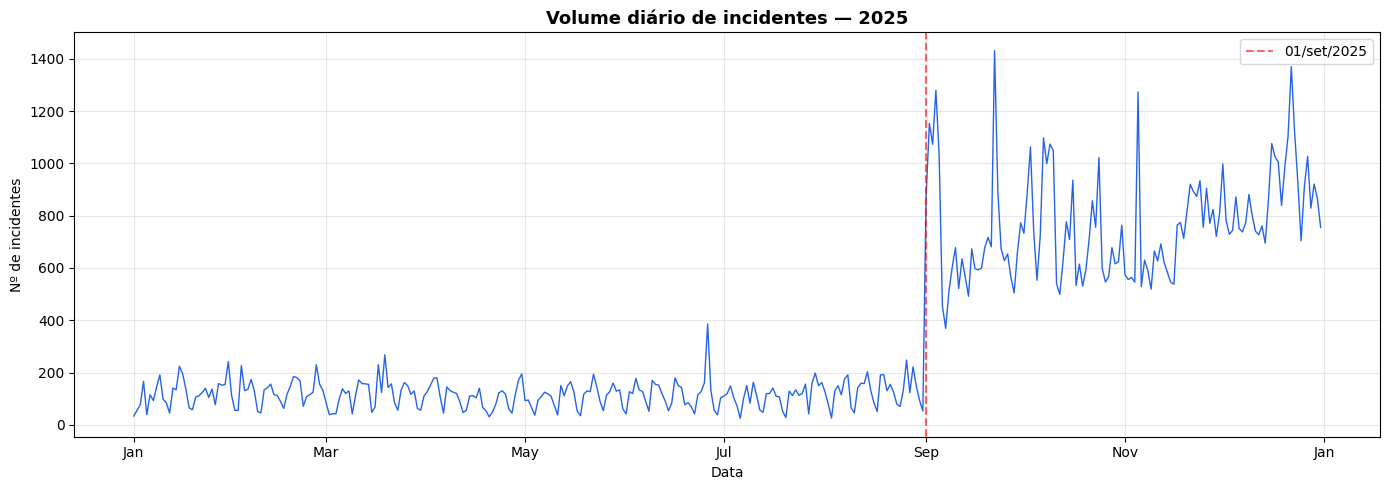

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(volume_diario_2025.index, volume_diario_2025.values, color='#2563eb', linewidth=1)
ax.set_title('Volume diário de incidentes — 2025', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Nº de incidentes')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.axvline(pd.Timestamp('2025-09-01'), color='red', linestyle='--', alpha=0.6, label='01/set/2025')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/volume_diario_2025.png', dpi=150)
plt.show()

O volume diário aumenta de forma acentuada a partir de setembro/2025. A mudança é
investigada de forma objetiva na Seção 6.

## 6. Mudança de Regime (Set/2025)

Comparação objetiva entre Jan–Ago/2025 e Set–Dez/2025.

In [14]:
periodo_1 = df_2025[df_2025['Aberto'] < '2025-09-01']
periodo_2 = df_2025[df_2025['Aberto'] >= '2025-09-01']

vol_diario_p1 = periodo_1.groupby(periodo_1['Aberto'].dt.date).size()
vol_diario_p2 = periodo_2.groupby(periodo_2['Aberto'].dt.date).size()

resumo_regime = pd.DataFrame({
    'Jan-Ago/2025': [
        len(periodo_1), round(vol_diario_p1.mean(), 1),
        round(periodo_1.groupby(periodo_1['Aberto'].dt.to_period('M')).size().mean(), 1),
        round(vol_diario_p1.median(), 1), round(vol_diario_p1.std(), 1)
    ],
    'Set-Dez/2025': [
        len(periodo_2), round(vol_diario_p2.mean(), 1),
        round(periodo_2.groupby(periodo_2['Aberto'].dt.to_period('M')).size().mean(), 1),
        round(vol_diario_p2.median(), 1), round(vol_diario_p2.std(), 1)
    ]
}, index=['Volume total', 'Média diária', 'Média mensal', 'Mediana diária', 'Desvio padrão diário'])

crescimento_pct = round((vol_diario_p2.mean() - vol_diario_p1.mean()) / vol_diario_p1.mean() * 100, 1)
print(resumo_regime)
print(f'\nCrescimento da média diária: {crescimento_pct}%')

                      Jan-Ago/2025  Set-Dez/2025
Volume total               28388.0       93423.0
Média diária                 116.8         765.8
Média mensal                3548.5       23355.8
Mediana diária               120.0         735.5
Desvio padrão diário          51.3         202.6

Crescimento da média diária: 555.5%


In [15]:
pct_monitoramento_p1 = round((periodo_1['Aberto por'] == 'Monitoramento').mean() * 100, 1)
pct_monitoramento_p2 = round((periodo_2['Aberto por'] == 'Monitoramento').mean() * 100, 1)
pct_team14_p1 = round((periodo_1['Grupo designado'] == 'Team14').mean() * 100, 1)
pct_team14_p2 = round((periodo_2['Grupo designado'] == 'Team14').mean() * 100, 1)
pct_sem_intervencao_p1 = round((periodo_1['Status'] == 'Sem Intervenção').mean() * 100, 1)
pct_sem_intervencao_p2 = round((periodo_2['Status'] == 'Sem Intervenção').mean() * 100, 1)

print(f'% Aberto por = Monitoramento:  Jan-Ago {pct_monitoramento_p1}% -> Set-Dez {pct_monitoramento_p2}%')
print(f'% Grupo designado = Team14:    Jan-Ago {pct_team14_p1}% -> Set-Dez {pct_team14_p2}%')
print(f'% Status = Sem Intervenção:    Jan-Ago {pct_sem_intervencao_p1}% -> Set-Dez {pct_sem_intervencao_p2}%')

print()
print('Distribuição de Prioridade, por período (%):')
dist_p1 = (periodo_1['Prioridade'].value_counts(normalize=True) * 100).round(1)
dist_p2 = (periodo_2['Prioridade'].value_counts(normalize=True) * 100).round(1)
pd.DataFrame({'Jan-Ago/2025 (%)': dist_p1, 'Set-Dez/2025 (%)': dist_p2})

% Aberto por = Monitoramento:  Jan-Ago 54.9% -> Set-Dez 94.8%
% Grupo designado = Team14:    Jan-Ago 38.6% -> Set-Dez 87.5%
% Status = Sem Intervenção:    Jan-Ago 0.3% -> Set-Dez 85.9%

Distribuição de Prioridade, por período (%):


,Jan-Ago/2025 (%),Set-Dez/2025 (%)
Prioridade,,
1 - Crítica,0.0,NaN
2 - Alta,19.9,10.7
3 - Média,58.7,26.3
4 - Baixa,20.4,62.9
5 - Muito Baixa,1.1,0.0


O crescimento de volume em Set–Dez/2025 coincide com o aumento simultâneo de três
indicadores: origem por monitoramento, atribuição ao Team14 e fechamento sem intervenção
humana, além de uma inversão na distribuição de prioridade, de maioria "3-Média" para
maioria "4-Baixa". O dataset não permite atribuir causalidade a essa associação, apenas
evidenciá-la; a investigação de ruído (Seção 8) aprofunda esses cruzamentos.

## 7. Prioridades e Séries P2/P3

Identificamos os rótulos literais de prioridade no dataset e construímos as séries diárias
de P2 (`2 - Alta`) e P3 (`3 - Média`), foco obrigatório de monitoramento definido na
Sprint 2.

In [16]:
dist_prioridade = df_2025['Prioridade'].value_counts()
dist_prioridade_pct = (df_2025['Prioridade'].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({'quantidade': dist_prioridade, 'percentual (%)': dist_prioridade_pct})

,quantidade,percentual (%)
Prioridade,,
4 - Baixa,64580,53.02
3 - Média,41260,33.87
2 - Alta,15645,12.84
5 - Muito Baixa,325,0.27
1 - Crítica,1,0.00


In [17]:
df_p2 = df_2025[df_2025['Prioridade'] == '2 - Alta']
df_p3 = df_2025[df_2025['Prioridade'] == '3 - Média']

volume_p2 = df_p2.groupby(df_p2['Aberto'].dt.date).size()
volume_p2.index = pd.to_datetime(volume_p2.index)
volume_p2 = volume_p2.reindex(calendario_2025, fill_value=0)

volume_p3 = df_p3.groupby(df_p3['Aberto'].dt.date).size()
volume_p3.index = pd.to_datetime(volume_p3.index)
volume_p3 = volume_p3.reindex(calendario_2025, fill_value=0)

print('P2 — dias com incidente:', (volume_p2 > 0).sum(), 'de', len(volume_p2),
      '| média diária:', round(volume_p2.mean(), 1), '| máx:', volume_p2.max())
print('P3 — dias com incidente:', (volume_p3 > 0).sum(), 'de', len(volume_p3),
      '| média diária:', round(volume_p3.mean(), 1), '| máx:', volume_p3.max())

p2_antes, p2_depois = volume_p2[volume_p2.index < '2025-09-01'].mean(), volume_p2[volume_p2.index >= '2025-09-01'].mean()
p3_antes, p3_depois = volume_p3[volume_p3.index < '2025-09-01'].mean(), volume_p3[volume_p3.index >= '2025-09-01'].mean()
print(f'\nP2 — média diária Jan-Ago: {p2_antes:.1f} | Set-Dez: {p2_depois:.1f}')
print(f'P3 — média diária Jan-Ago: {p3_antes:.1f} | Set-Dez: {p3_depois:.1f}')

P2 — dias com incidente: 365 de 365 | média diária: 42.9 | máx: 684
P3 — dias com incidente: 365 de 365 | média diária: 113.0 | máx: 849

P2 — média diária Jan-Ago: 23.2 | Set-Dez: 82.0
P3 — média diária Jan-Ago: 68.6 | Set-Dez: 201.6


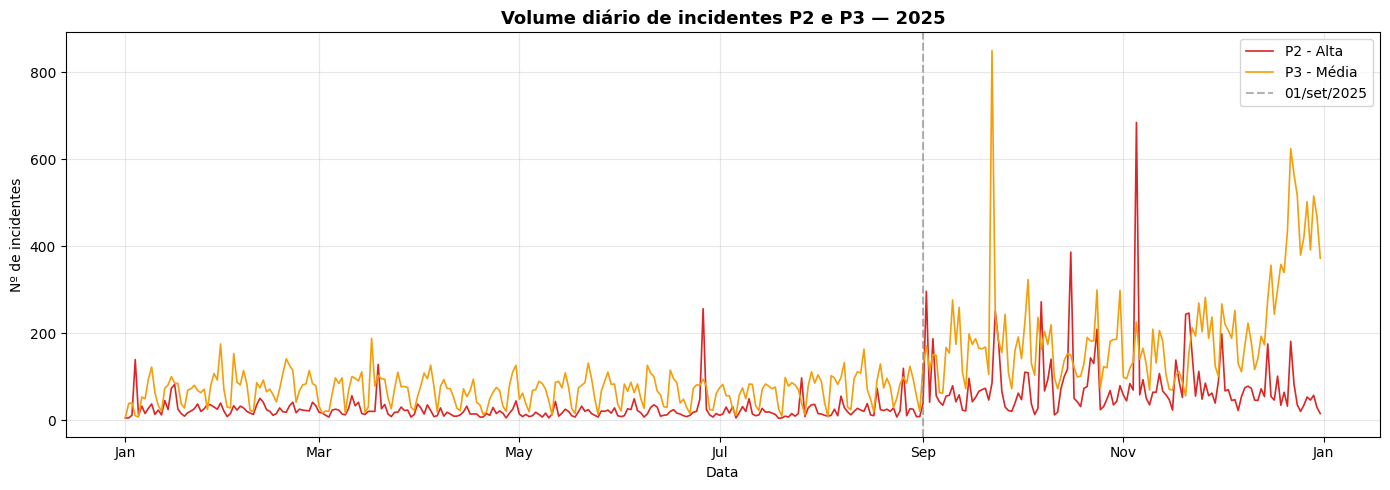

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(volume_p2.index, volume_p2.values, label='P2 - Alta', color='#dc2626', linewidth=1.2)
ax.plot(volume_p3.index, volume_p3.values, label='P3 - Média', color='#f59e0b', linewidth=1.2)
ax.axvline(pd.Timestamp('2025-09-01'), color='gray', linestyle='--', alpha=0.6, label='01/set/2025')
ax.set_title('Volume diário de incidentes P2 e P3 — 2025', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Nº de incidentes')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/volume_p2_p3_2025.png', dpi=150)
plt.show()

P2 e P3 têm volume diário em todos os 365 dias, sem zeros, com sazonalidade visível —
volume suficiente para sustentar um modelo diário. Ambas cresceram após setembro/2025
(P2: 23,2 → 82,0; P3: 68,6 → 201,6), mas em proporção menor do que o crescimento das demais
prioridades, coerente com a inversão de distribuição observada na Seção 6.

## 8. Ruído Operacional e Campos Seguros para Modelagem

Investigamos a associação `Monitoramento → Sem Intervenção` e separamos os campos
disponíveis **na abertura** dos campos conhecidos **somente após o fechamento**, para uso
seguro em capacidades futuras (classificador de ruído), sem risco de leakage.

In [19]:
print('% Sem Intervenção por Aberto por:')
print((pd.crosstab(df_2025['Aberto por'], df_2025['Status'], normalize='index') * 100).round(1))

% Sem Intervenção por Aberto por:
Status         Aguardando Problema  Encerrado  Encerrado Automaticamente  \
Aberto por                                                                 
Manual                         0.0       40.6                       59.3   
Monitoramento                  0.0        7.8                       15.1   

Status         Sem Intervenção  
Aberto por                      
Manual                     0.2  
Monitoramento             77.2  


In [20]:
print('% Sem Intervenção por Prioridade:')
print((pd.crosstab(df_2025['Prioridade'], df_2025['Status'], normalize='index') * 100).round(1))

% Sem Intervenção por Prioridade:
Status           Aguardando Problema  Encerrado  Encerrado Automaticamente  \
Prioridade                                                                   
1 - Crítica                      0.0      100.0                        0.0   
2 - Alta                         0.0       59.7                        0.3   
3 - Média                        0.0       13.5                       42.9   
4 - Baixa                        0.0        0.5                       12.6   
5 - Muito Baixa                  0.0       12.9                       86.8   

Status           Sem Intervenção  
Prioridade                        
1 - Crítica                  0.0  
2 - Alta                    40.0  
3 - Média                   43.5  
4 - Baixa                   86.9  
5 - Muito Baixa              0.3  


In [21]:
print('% Sem Intervenção pelos 5 principais Grupos designados:')
top_grupos = df_2025['Grupo designado'].value_counts().head(5).index
sub = df_2025[df_2025['Grupo designado'].isin(top_grupos)]
print((pd.crosstab(sub['Grupo designado'], sub['Status'], normalize='index') * 100).round(1))

% Sem Intervenção pelos 5 principais Grupos designados:
Status           Aguardando Problema  Encerrado  Encerrado Automaticamente  \
Grupo designado                                                              
Team05                           0.0       34.7                       48.3   
Team09                           0.0       46.3                       42.7   
Team11                           0.0       29.3                       70.3   
Team12                           0.0       24.8                       16.4   
Team14                           0.0        6.4                       12.1   

Status           Sem Intervenção  
Grupo designado                   
Team05                      17.0  
Team09                      11.0  
Team11                       0.4  
Team12                      58.8  
Team14                      81.5  


In [22]:
campos_leakage = pd.DataFrame({
    'Campo': ['Prioridade', 'Aberto por', 'Grupo designado', 'Produto/Categoria/Subcategoria',
              'Item de configuração', 'Duração', 'Resolvido', 'Código de fechamento',
              'Solução', 'KPI Violado?', 'Status'],
    'Disponível na abertura?': ['Sim', 'Sim', 'Não confirmado', 'Sim (parcial, ~36%)', 'Sim (quase sempre)',
                                  'Não', 'Não', 'Não', 'Não', 'Não', 'Não (é o próprio target)'],
    'Uso seguro como feature': ['Sim', 'Sim', 'Não utilizado no modelo final (por precaução)', 'Sim, com tratamento de nulo',
                                  'Avaliar', 'NÃO (leakage)', 'NÃO (leakage)',
                                  'NÃO (leakage)', 'NÃO (leakage)', 'NÃO (leakage)',
                                  'É o target, não feature']
})
campos_leakage

,Campo,Disponível na abertura?,Uso seguro como feature
0,Prioridade,Sim,Sim
1,Aberto por,Sim,Sim
2,Grupo designado,Não confirmado,Não utilizado no modelo final (por precaução)
3,Produto/Categoria/Subcategoria,"Sim (parcial, ~36%)","Sim, com tratamento de nulo"
4,Item de configuração,Sim (quase sempre),Avaliar
5,Duração,Não,NÃO (leakage)
6,Resolvido,Não,NÃO (leakage)
7,Código de fechamento,Não,NÃO (leakage)
8,Solução,Não,NÃO (leakage)
9,KPI Violado?,Não,NÃO (leakage)


`Aberto por` e `Prioridade` — ambos disponíveis no momento da abertura carregam sinal forte
sobre a probabilidade de o incidente terminar como `Sem Intervenção` (77,2% quando aberto por
monitoramento; 81,5% no Team14). Um classificador de ruído é viável sem leakage, desde que
utilize apenas os campos marcados como "Sim" na tabela acima. `Duração`, `Resolvido`, `Código
de fechamento`, `Solução` e `KPI Violado?` só existem após o fechamento e não podem ser
usados como features de previsão.

`Grupo designado` mostra sinal forte (81,5% Sem Intervenção no Team14), mas sua disponibilidade
no instante exato da abertura não é confirmada pelo dicionário de dados. Por precaução, o campo
não é utilizado no modelo final de triagem (`03_TRIAGEM_ENTREGA_FINAL`).

## 9. Construção e Exportação da Série Diária

Consolidamos a série diária final (`data`, `volume_total`, `volume_p2`, `volume_p3`,
`volume_outras_prioridades`) para uso no Motor Preditivo.

In [23]:
serie_diaria = pd.DataFrame({
    'data': calendario_2025,
    'volume_total': volume_diario_2025.values,
    'volume_p2': volume_p2.values,
    'volume_p3': volume_p3.values
})
serie_diaria['volume_outras_prioridades'] = serie_diaria['volume_total'] - serie_diaria['volume_p2'] - serie_diaria['volume_p3']

assert serie_diaria['data'].is_unique, 'Existem datas duplicadas!'
assert serie_diaria['data'].is_monotonic_increasing, 'Datas fora de ordem!'
assert serie_diaria.isnull().sum().sum() == 0, 'Existem valores nulos na série!'
assert (serie_diaria['volume_outras_prioridades'] >= 0).all(), 'volume_outras_prioridades negativo!'

serie_diaria['data'] = serie_diaria['data'].dt.strftime('%Y-%m-%d')
print('Linhas:', len(serie_diaria), '| Datas duplicadas:', serie_diaria['data'].duplicated().sum(),
      '| Nulos:', serie_diaria.isnull().sum().sum())
serie_diaria.head()

Linhas: 365 | Datas duplicadas: 0 | Nulos: 0


,data,volume_total,volume_p2,volume_p3,volume_outras_prioridades
0,2025-01-01,34,5,6,23
1,2025-01-02,55,5,38,12
2,2025-01-03,77,11,40,26
3,2025-01-04,166,139,10,17
4,2025-01-05,39,11,7,21


In [27]:
serie_diaria.to_csv(PROCESSED_PATH, index=False)
print('Arquivo salvo em:', PROCESSED_PATH)
print('Shape final:', serie_diaria.shape)

Arquivo salvo em: ../data/processed/serie_diaria_2025.csv
Shape final: (365, 5)


## 10. Conclusão

O dataset possui uma mudança real a partir de setembro/2025
(+555,5% na média diária), associada ao crescimento simultâneo de tickets abertos por
monitoramento, atribuídos ao Team14 e fechados sem intervenção — o padrão de ruído
operacional que motiva o projeto. P2 e P3 têm volume diário suficiente para modelagem
própria, e os campos disponíveis na abertura do incidente (`Prioridade`, `Aberto por`,
`Grupo designado`) já mostram sinal sobre esse ruído, sem risco de leakage.

A série diária exportada (`serie_diaria_2025.csv`) é a base utilizada integralmente pelo
Motor Preditivo. A hipótese de treinar apenas no regime recente (Set–Dez/2025), levantada a
partir da mudança de regime identificada aqui, foi validada empiricamente no
`02_modelagem_previsao` (Seção 3.1): o regime recente produziu menor erro agregado e maior
estabilidade do que o histórico completo com indicador de regime.